# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("Imports done")

Imports done


# Load Dataset


In [2]:
rfm = pd.read_csv('../data/processed/rfm_labeled.csv')
print(f"Loaded: {rfm.shape}")
print(rfm['Segment'].value_counts())

Loaded: (4338, 6)
Segment
At Risk                2250
Lost Customers         1014
Potential Loyalists     793
Loyal Customers         206
Champions                75
Name: count, dtype: int64


# Feature Scaling

In [3]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].values

scaler_ae = StandardScaler()
X_scaled = scaler_ae.fit_transform(X)

with open('../models/scaler_ae.pkl', 'wb') as f:
    pickle.dump(scaler_ae, f)

print(f"Input shape  : {X_scaled.shape}")
print(f"Scaler saved")

Input shape  : (4338, 3)
Scaler saved


# Build Autoencoder

In [4]:
# Architecture: 3 → 8 → 2 → 8 → 3
# The bottleneck is hidden_layer_sizes[1] = 2 nodes
# MLPRegressor trains the full encode+decode pipeline

autoencoder = MLPRegressor(
    hidden_layer_sizes=(8, 2, 8),   # compress to 2 at bottleneck
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False
)

autoencoder.fit(X_scaled, X_scaled)  # input = output (reconstruction)

# Check reconstruction quality
X_reconstructed = autoencoder.predict(X_scaled)
mse = mean_squared_error(X_scaled, X_reconstructed)
print(f"Reconstruction MSE : {mse:.6f}")
print(f"Lower = better — anything below 0.05 is excellent")

# Save autoencoder
with open('../models/autoencoder_model.pkl', 'wb') as f:
    pickle.dump(autoencoder, f)
print("autoencoder_model.pkl saved")

Reconstruction MSE : 0.024826
Lower = better — anything below 0.05 is excellent
autoencoder_model.pkl saved


# Bottleneck Features

In [5]:
# To get the 2D bottleneck representation we run a
# partial forward pass — stopping at layer index 1 (the 2-node layer)

from sklearn.utils.extmath import safe_sparse_dot

def get_encoded_features(model, X):
    """Extract 2D bottleneck features from trained MLPRegressor."""
    activations = X.copy()
    # Forward pass through first 2 layers only (8 nodes → 2 nodes)
    for i in range(2):
        W = model.coefs_[i]
        b = model.intercepts_[i]
        activations = np.maximum(0, safe_sparse_dot(activations, W) + b)
    return activations

X_encoded = get_encoded_features(autoencoder, X_scaled)

print(f"Original shape : {X_scaled.shape}")   # (4338, 3)
print(f"Encoded shape  : {X_encoded.shape}")  # (4338, 2)
print("Bottleneck features extracted")

Original shape : (4338, 3)
Encoded shape  : (4338, 2)
Bottleneck features extracted


# Visuals

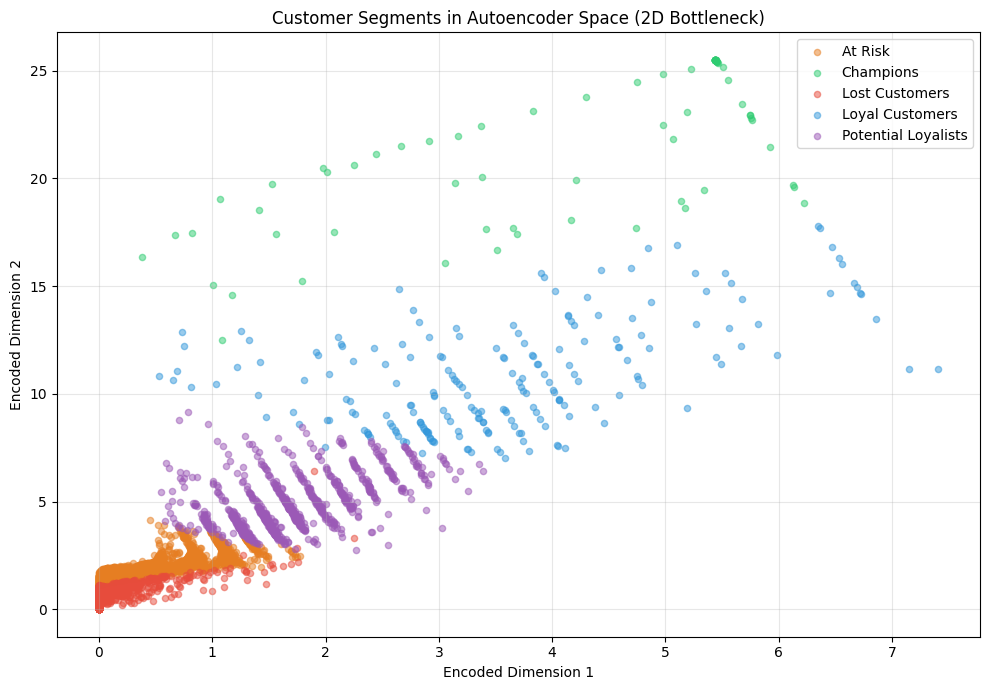

If segments appear separated in 2D — autoencoder learned meaningful structure


In [6]:
segment_colors = {
    'Champions':           '#2ecc71',
    'Loyal Customers':     '#3498db',
    'Potential Loyalists': '#9b59b6',
    'At Risk':             '#e67e22',
    'Lost Customers':      '#e74c3c'
}

plt.figure(figsize=(10, 7))
for seg, grp in rfm.groupby('Segment'):
    idx = grp.index
    plt.scatter(X_encoded[idx, 0], X_encoded[idx, 1],
                label=seg, alpha=0.5, s=20,
                color=segment_colors.get(seg, 'gray'))

plt.title('Customer Segments in Autoencoder Space (2D Bottleneck)')
plt.xlabel('Encoded Dimension 1')
plt.ylabel('Encoded Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/autoencoder_space.png', dpi=150)
plt.show()
print("If segments appear separated in 2D — autoencoder learned meaningful structure")

In [7]:
# Save as numpy array for classifier notebook
np.save('../data/processed/X_encoded.npy', X_encoded)
print("X_encoded.npy saved")

X_encoded.npy saved
